# Speech Information Processing — Week 2 Hands-on #1
## Clean Sample Notebook: Tasks A–D

This notebook implements the Week 2 hands-on tasks.

Tasks:

- **Task A**: reconstruction metric $\rho(D)$
- **Task B**: decorrelation metrics $\phi_L$, $\phi_c$, and $\Delta \phi$
- **Task C**: statistical comparison between two conditions
- **Task D**: mini sensitivity experiment

Baseline configuration:

- sampling rate: 16 kHz
- frame length: 25 ms
- hop length: 10 ms
- number of Mel bands: $K=40$
- $f_{min}=20$ Hz
- $f_{max}=8000$ Hz
- number of MFCC coefficients: $D=13$
- numerical constant: $\epsilon = 10^{-10}$

This notebook is intended as a clean GitHub sample.

In [70]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display
import yaml

from scipy import stats
from scipy.fft import dct, idct

print("Imports completed.")

Imports completed.


## 1. Reproducibility and paths

In [71]:
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)

ROOT = Path("..")   # notebook assumed inside notebooks/
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "figs"
TABLE_DIR = ROOT / "tables"
CONFIG_DIR = ROOT / "configs"
LOG_DIR = ROOT / "logs"

print(f"Seed fixed to {SEED}")
print("ROOT =", ROOT.resolve())

Seed fixed to 1234
ROOT = /Users/tmatsui/Dropbox/SLAI/SIP


## 2. Baseline configuration

In [72]:
# Reproducibility seed

config = {
    "fs": 16000,
    "frame_length_ms": 25,
    "hop_length_ms": 10,
    "n_fft": 512,
    "n_mels": 40,
    "fmin": 20,
    "fmax": 8000,
    "D": 13,
    "epsilon": 1e-10,
    "cmvn_scope": "utterance",
    "seed": SEED,
}

# Ensure directories exist
for d in [DATA_DIR, FIG_DIR, TABLE_DIR, CONFIG_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Save configuration
with open(CONFIG_DIR / "w2_base_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

with open(CONFIG_DIR / "w2_base_config.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump(config, f, sort_keys=False)

print("Configuration saved.")
print("Seed =", SEED)
print("Config directory =", CONFIG_DIR)

config

Configuration saved.
Seed = 1234
Config directory = ../configs


{'fs': 16000,
 'frame_length_ms': 25,
 'hop_length_ms': 10,
 'n_fft': 512,
 'n_mels': 40,
 'fmin': 20,
 'fmax': 8000,
 'D': 13,
 'epsilon': 1e-10,
 'cmvn_scope': 'utterance',
 'seed': 1234}

## 3. Helper functions

We define helper functions for:

- silence trimming
- log-Mel extraction
- CMVN
- MFCC computation
- inverse transform for reconstruction
- correlation-based metrics

In [73]:
def trim_silence(y, top_db=30):
    yt, _ = librosa.effects.trim(y, top_db=top_db)
    return yt.astype(np.float32)


def compute_logmel(
    y,
    sr,
    frame_length_ms=25,
    hop_length_ms=10,
    n_fft=512,
    n_mels=40,
    fmin=20,
    fmax=8000,
    epsilon=1e-10,
    window="hann",
):
    win_length = int(round(frame_length_ms * sr / 1000))
    hop_length = int(round(hop_length_ms * sr / 1000))

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        window=window,
        center=True,
        power=2.0,
        n_mels=n_mels,
        fmin=fmin,
        fmax=fmax,
    )

    logmel = np.log(mel + epsilon)
    return logmel.astype(np.float32)


def cmvn(X, axis=1, epsilon=1e-10):
    mu = np.mean(X, axis=axis, keepdims=True)
    sigma = np.std(X, axis=axis, keepdims=True)
    return ((X - mu) / (sigma + epsilon)).astype(np.float32)


def compute_mfcc_from_logmel(logmel, D=13):
    mfcc_full = dct(logmel, type=2, axis=0, norm="ortho")
    return mfcc_full[:D, :].astype(np.float32)


def reconstruct_logmel_from_mfcc(mfcc_trunc, K):
    D, T = mfcc_trunc.shape
    padded = np.zeros((K, T), dtype=np.float32)
    padded[:D, :] = mfcc_trunc
    logmel_hat = idct(padded, type=2, axis=0, norm="ortho")
    return logmel_hat.astype(np.float32)


def flatten_corr(A, B):
    a = A.reshape(-1)
    b = B.reshape(-1)
    return np.corrcoef(a, b)[0, 1]


def corr_matrix_over_time(X):
    return np.corrcoef(X)


def mean_abs_offdiag(R):
    D = R.shape[0]
    mask = ~np.eye(D, dtype=bool)
    return np.mean(np.abs(R[mask]))

## 4. Prepare one example waveform

Use one of the following options:

- record a short speech sample on your phone and save it as `data/sample.wav`
- place any short mono speech waveform at `data/sample.wav`
- optionally generate a synthetic sample for testing

In [74]:
audio_path = DATA_DIR / "sample.wav"

if not audio_path.exists():
    raise FileNotFoundError(
        f"{audio_path} was not found. Please place sample.wav in the data folder."
    )

y, sr = librosa.load(audio_path, sr=16000, mono=True)
y = trim_silence(y)

print("Loaded:", audio_path)
print("Sampling rate:", sr)
print("Duration:", len(y)/sr)

Loaded: ../data/sample.wav
Sampling rate: 16000
Duration: 4.544


In [75]:
from IPython.display import Audio

Audio(y, rate=sr)

## Step 5 — Baseline log-Mel, CMVN, and MFCC

We now compute the baseline spectral features used in the Week 2 pipeline.

Processing steps:

waveform  
→ STFT  
→ Mel filterbank  
→ log-Mel  
→ CMVN  
→ MFCC

The configuration follows the Week 2 defaults:

- frame length = 25 ms  
- hop length = 10 ms  
- number of Mel bands = $K = 40$  
- $f_{min} = 20$ Hz  
- $f_{max} = 8000$ Hz  
- MFCC dimension $D = 13$

In [76]:
# Compute log-Mel spectrogram

L = compute_logmel(
    y=y,
    sr=sr,
    frame_length_ms=config["frame_length_ms"],
    hop_length_ms=config["hop_length_ms"],
    n_fft=config["n_fft"],
    n_mels=config["n_mels"],
    fmin=config["fmin"],
    fmax=config["fmax"],
    epsilon=config["epsilon"],
)

# Apply CMVN
L_cmvn = cmvn(L, axis=1, epsilon=config["epsilon"])

# Compute MFCC
C = compute_mfcc_from_logmel(L_cmvn, D=config["D"])

print("log-Mel shape:", L.shape)
print("CMVN log-Mel shape:", L_cmvn.shape)
print("MFCC shape:", C.shape)

log-Mel shape: (40, 455)
CMVN log-Mel shape: (40, 455)
MFCC shape: (13, 455)


### Visualize log-Mel and MFCC

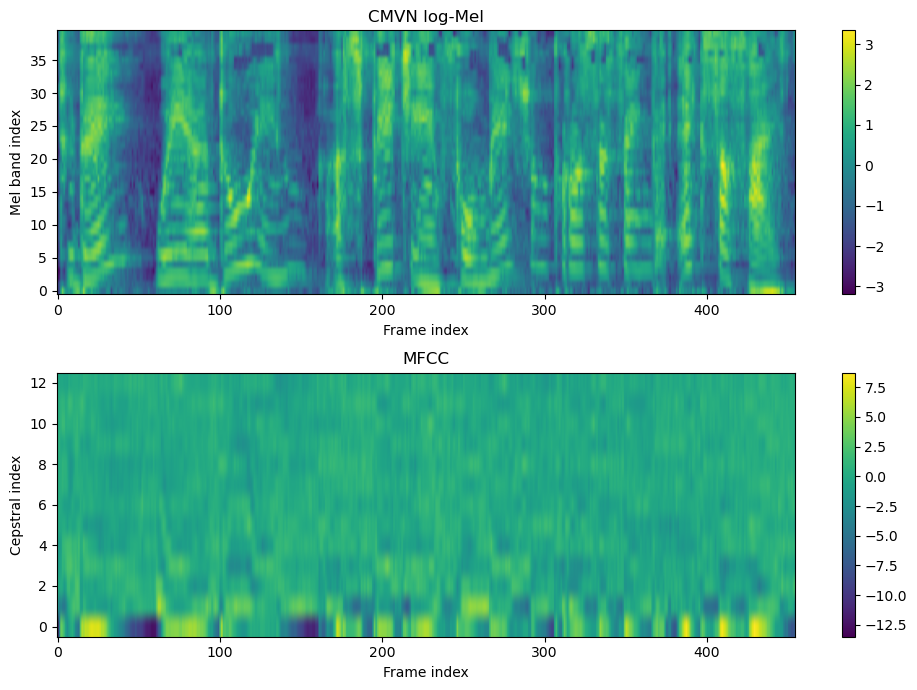

In [77]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

im0 = axes[0].imshow(L_cmvn, aspect="auto", origin="lower")
axes[0].set_title("CMVN log-Mel")
axes[0].set_xlabel("Frame index")
axes[0].set_ylabel("Mel band index")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(C, aspect="auto", origin="lower")
axes[1].set_title("MFCC")
axes[1].set_xlabel("Frame index")
axes[1].set_ylabel("Cepstral index")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

# Task A — Reconstruction Metric $\rho(D)$

We measure how much spectral information is preserved when only the first $D$ MFCC coefficients are kept.

Processing idea:

original log-Mel spectrum $L$
→ DCT
→ MFCC
→ keep first $D$ coefficients
→ inverse transform
→ reconstructed log-Mel $\hat{L}(D)$

The reconstruction metric is

$\rho(D) = Corr(L, \hat{L}(D))$

Interpretation:

- $\rho(D) \approx 1$ means the reconstructed spectrum is close to the original
- smaller $\rho(D)$ means more information loss
- typically, larger $D$ gives larger $\rho(D)$

In [78]:
# Reconstruct log-Mel from truncated MFCC
L_hat = reconstruct_logmel_from_mfcc(C, K=config["n_mels"])

# Reconstruction metric
rho_D = flatten_corr(L_cmvn, L_hat)

print(f"rho(D={config['D']}) = {rho_D:.4f}")

rho(D=13) = 0.9410


## Save Task A result

In [79]:
df_task_a = pd.DataFrame(
    [{
        "D": config["D"],
        "rho_D": rho_D,
        "n_mels": config["n_mels"],
        "fmin": config["fmin"],
        "fmax": config["fmax"],
    }]
)

df_task_a.to_csv(TABLE_DIR / "taskA_rho.csv", index=False)
df_task_a

,D,rho_D,n_mels,fmin,fmax
0,13,0.940958,40,20,8000


## Visual comparison: original vs reconstructed log-Mel

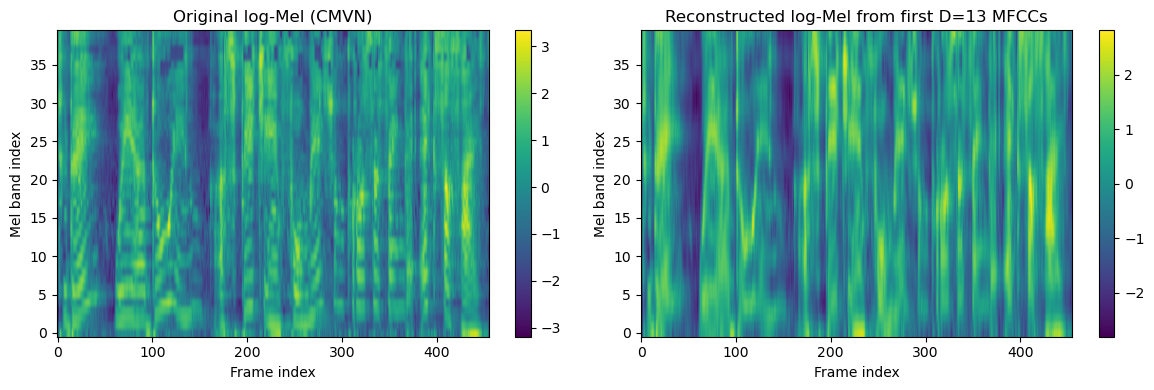

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(L_cmvn, aspect="auto", origin="lower")
axes[0].set_title("Original log-Mel (CMVN)")
axes[0].set_xlabel("Frame index")
axes[0].set_ylabel("Mel band index")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(L_hat, aspect="auto", origin="lower")
axes[1].set_title(f"Reconstructed log-Mel from first D={config['D']} MFCCs")
axes[1].set_xlabel("Frame index")
axes[1].set_ylabel("Mel band index")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

## Optional check: compare several values of $D$

This helps confirm the expected trend:
larger $D$ usually gives larger $\rho(D)$.

In [81]:
D_list = [5, 10, 13, 20]
task_a_curve = []

for D_val in D_list:
    C_D = compute_mfcc_from_logmel(L_cmvn, D=D_val)
    L_hat_D = reconstruct_logmel_from_mfcc(C_D, K=config["n_mels"])
    rho_val = flatten_corr(L_cmvn, L_hat_D)
    task_a_curve.append({"D": D_val, "rho_D": rho_val})

df_task_a_curve = pd.DataFrame(task_a_curve)
df_task_a_curve.to_csv(TABLE_DIR / "taskA_rho_curve.csv", index=False)
df_task_a_curve

,D,rho_D
0,5,0.885403
1,10,0.922042
2,13,0.940958
3,20,0.970810


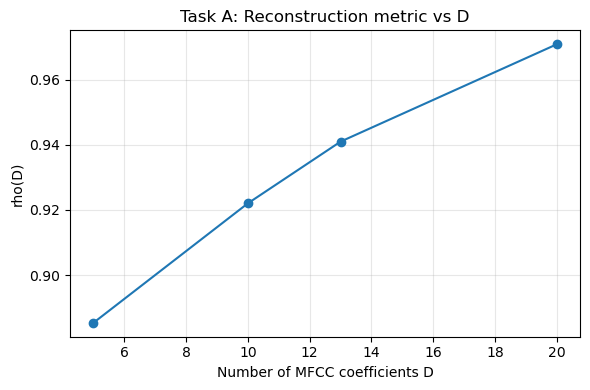

In [82]:
plt.figure(figsize=(6, 4))
plt.plot(df_task_a_curve["D"], df_task_a_curve["rho_D"], marker="o")
plt.title("Task A: Reconstruction metric vs D")
plt.xlabel("Number of MFCC coefficients D")
plt.ylabel("rho(D)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Task B — Decorrelation Metrics $\phi_L$, $\phi_c$, and $\Delta \phi$

In this task, we quantify whether MFCC features are less correlated than log-Mel features.

We first compute:

- the correlation matrix of log-Mel features: $R_L$
- the correlation matrix of MFCC features: $R_c$

Then we summarize each matrix by one scalar:

$\phi = \text{mean}(|\text{off-diag}(R)|)$

Interpretation:

- smaller $\phi$ means weaker overall correlation
- $\Delta \phi = \phi_c - \phi_L < 0$ means MFCC is more decorrelated than log-Mel

Why do we use the off-diagonal part?

- diagonal entries are always 1, because each variable is perfectly correlated with itself
- off-diagonal entries measure correlation between different bands or coefficients
- therefore, the off-diagonal part tells us how redundant the representation is

In [83]:
# Correlation matrices
R_L = corr_matrix_over_time(L_cmvn)
R_c = corr_matrix_over_time(C)

print("R_L shape:", R_L.shape)
print("R_c shape:", R_c.shape)

R_L shape: (40, 40)
R_c shape: (13, 13)


## Compute scalar decorrelation metrics

We compute:

- $\phi_L$ for log-Mel
- $\phi_c$ for MFCC
- $\Delta \phi = \phi_c - \phi_L$

In [84]:
phi_L = mean_abs_offdiag(R_L)
phi_c = mean_abs_offdiag(R_c)
delta_phi = phi_c - phi_L

print(f"phi_L   = {phi_L:.4f}")
print(f"phi_c   = {phi_c:.4f}")
print(f"Delta phi = {delta_phi:.4f}")

phi_L   = 0.5139
phi_c   = 0.1663
Delta phi = -0.3476


## Save Task B result

In [85]:
df_task_b = pd.DataFrame(
    [{
        "phi_L": phi_L,
        "phi_c": phi_c,
        "delta_phi": delta_phi,
    }]
)

df_task_b.to_csv(TABLE_DIR / "taskB_phi.csv", index=False)
df_task_b

,phi_L,phi_c,delta_phi
0,0.51389,0.166284,-0.347606


## Visualize the correlation matrices

A heatmap makes the difference easier to see:

- log-Mel usually has stronger neighboring correlations
- MFCC is expected to be more decorrelated after DCT

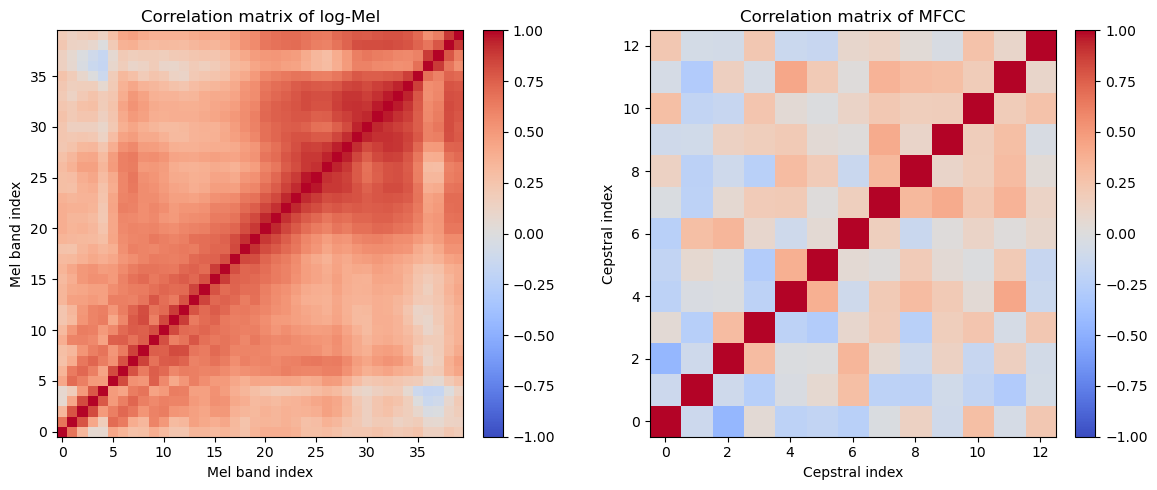

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(R_L, vmin=-1, vmax=1, origin="lower", cmap="coolwarm")
axes[0].set_title("Correlation matrix of log-Mel")
axes[0].set_xlabel("Mel band index")
axes[0].set_ylabel("Mel band index")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(R_c, vmin=-1, vmax=1, origin="lower", cmap="coolwarm")
axes[1].set_title("Correlation matrix of MFCC")
axes[1].set_xlabel("Cepstral index")
axes[1].set_ylabel("Cepstral index")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIG_DIR / "taskB_correlation_heatmaps.png", dpi=150)
plt.show()

## Optional diagnostic: distribution of off-diagonal correlations

This plot helps compare redundancy more directly.

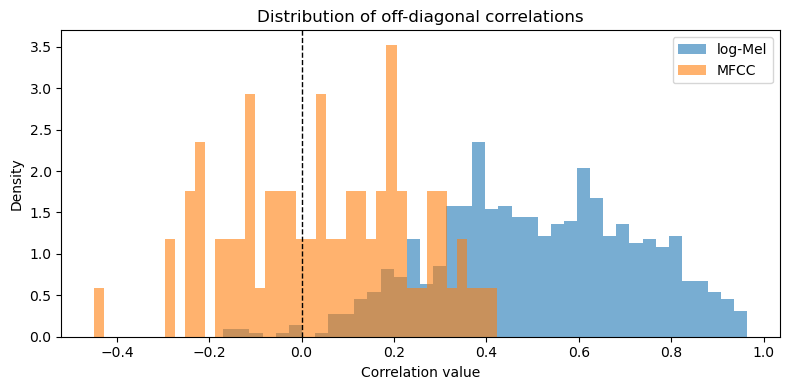

In [87]:
def get_offdiag_values(R):
    D = R.shape[0]
    mask = ~np.eye(D, dtype=bool)
    return R[mask]

offdiag_L = get_offdiag_values(R_L)
offdiag_c = get_offdiag_values(R_c)

plt.figure(figsize=(8, 4))
plt.hist(offdiag_L, bins=40, alpha=0.6, label="log-Mel", density=True)
plt.hist(offdiag_c, bins=40, alpha=0.6, label="MFCC", density=True)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Distribution of off-diagonal correlations")
plt.xlabel("Correlation value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "taskB_offdiag_hist.png", dpi=150)
plt.show()

## Interpretation note

To interpret the result:

- if $\phi_c < \phi_L$, MFCC is less correlated than log-Mel
- if $\Delta \phi < 0$, DCT has reduced feature redundancy
- if the difference is small, the decorrelation effect may be weak for this signal or this configuration

In many cases, log-Mel has stronger local correlation because neighboring Mel filters overlap.
After DCT, MFCC coefficients are expected to be less correlated.

In [88]:
if delta_phi < 0:
    interpretation = "MFCC is more decorrelated than log-Mel."
elif delta_phi > 0:
    interpretation = "MFCC is less decorrelated than log-Mel for this example."
else:
    interpretation = "No difference in the scalar decorrelation metric."

print("Interpretation:")
print(interpretation)

Interpretation:
MFCC is more decorrelated than log-Mel.


## Interim summary after Tasks A and B

So far we have computed:

- Task A: reconstruction metric $\rho(D)$
- Task B: decorrelation metrics $\phi_L$, $\phi_c$, and $\Delta \phi$

Next, in Task C, we will ask:

Are the observed differences statistically reliable?

# Task C — Statistical Comparison

In Tasks A and B, we computed feature metrics.

Now we ask:

Are the observed differences statistically reliable?

We compare two conditions:

- **Condition A**: baseline pipeline
- **Condition B**: baseline + simple temporal smoothing (RASTA-like example)

In this sample notebook, Condition B is a simple temporally smoothed variant used only to illustrate the statistical comparison procedure.
It is not a full implementation of RASTA.

For each segment, we compute summary metrics such as:

- $\rho(D)$
- $\phi_L$
- $\phi_c$
- $\Delta \phi$

Then we compare the two conditions statistically.

We report:

- mean difference $\Delta \mu$
- 95% confidence interval
- p-value
- effect size (Cohen's $d$)

If variance homogeneity is doubtful, Welch's t-test is safer than the pooled t-test.

## Helper functions for Task C

We add helper functions for:

- segmenting the waveform
- simple temporal smoothing
- per-segment metric extraction
- confidence interval
- Cohen's $d$

In [89]:
def moving_average_time(X, kernel_size=5):
    """
    Simple temporal smoothing over time axis.
    X: [D, T]
    """
    pad = kernel_size // 2
    X_pad = np.pad(X, ((0, 0), (pad, pad)), mode="edge")
    out = np.zeros_like(X)

    for t in range(X.shape[1]):
        out[:, t] = np.mean(X_pad[:, t:t+kernel_size], axis=1)

    return out.astype(np.float32)


def split_into_segments(y, sr, segment_sec=0.8, min_sec=0.4):
    """
    Split waveform into fixed-length segments.
    Returns a list of waveform segments.
    """
    seg_len = int(segment_sec * sr)
    min_len = int(min_sec * sr)

    segments = []
    start = 0
    while start < len(y):
        end = min(start + seg_len, len(y))
        seg = y[start:end]
        if len(seg) >= min_len:
            segments.append(seg.astype(np.float32))
        start += seg_len

    return segments


def compute_metrics_for_one_segment(y_seg, sr, config, smooth_logmel=False):
    """
    Compute Task A/B metrics for one segment.
    Returns a dict with rho_D, phi_L, phi_c, delta_phi.
    """
    L = compute_logmel(
        y=y_seg,
        sr=sr,
        frame_length_ms=config["frame_length_ms"],
        hop_length_ms=config["hop_length_ms"],
        n_fft=config["n_fft"],
        n_mels=config["n_mels"],
        fmin=config["fmin"],
        fmax=config["fmax"],
        epsilon=config["epsilon"],
    )

    # CMVN on log-Mel
    L_cmvn = cmvn(L, axis=1, epsilon=config["epsilon"])

    # Optional simple temporal smoothing (RASTA-like placeholder)
    if smooth_logmel:
        L_used = moving_average_time(L_cmvn, kernel_size=5)
    else:
        L_used = L_cmvn

    # MFCC
    C = compute_mfcc_from_logmel(L_used, D=config["D"])

    # Reconstruction
    L_hat = reconstruct_logmel_from_mfcc(C, K=config["n_mels"])
    rho_D = flatten_corr(L_used, L_hat)

    # Correlation matrices
    R_L = corr_matrix_over_time(L_used)
    R_c = corr_matrix_over_time(C)

    # Scalar metrics
    phi_L = mean_abs_offdiag(R_L)
    phi_c = mean_abs_offdiag(R_c)
    delta_phi = phi_c - phi_L

    return {
        "rho_D": rho_D,
        "phi_L": phi_L,
        "phi_c": phi_c,
        "delta_phi": delta_phi,
    }


def mean_ci(x, alpha=0.05):
    """
    Mean and normal-approximation CI.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    mean_x = np.mean(x)
    se = np.std(x, ddof=1) / np.sqrt(n) if n > 1 else 0.0
    z = stats.norm.ppf(1 - alpha / 2)
    lower = mean_x - z * se
    upper = mean_x + z * se
    return mean_x, lower, upper


def cohens_d(x, y):
    """
    Cohen's d for two independent samples.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    nx = len(x)
    ny = len(y)

    vx = np.var(x, ddof=1)
    vy = np.var(y, ddof=1)

    pooled = ((nx - 1) * vx + (ny - 1) * vy) / (nx + ny - 2)
    sp = np.sqrt(pooled)

    if sp == 0:
        return 0.0

    return (np.mean(x) - np.mean(y)) / sp

## Create segments for statistical comparison

For the sample notebook, we split one waveform into short segments.

This gives us repeated observations for a simple statistical comparison.
In a real experiment, utterance-level comparison is preferable.

In [90]:
segments = split_into_segments(y, sr, segment_sec=0.8, min_sec=0.4)

print("Number of segments:", len(segments))
print("Segment lengths (samples):", [len(seg) for seg in segments])

Number of segments: 6
Segment lengths (samples): [12800, 12800, 12800, 12800, 12800, 8704]


## Condition A vs Condition B

- **Condition A**: baseline
- **Condition B**: baseline + simple temporal smoothing

In [91]:
rows_A = []
rows_B = []

for i, seg in enumerate(segments):
    metrics_A = compute_metrics_for_one_segment(seg, sr, config, smooth_logmel=False)
    metrics_B = compute_metrics_for_one_segment(seg, sr, config, smooth_logmel=True)

    metrics_A["segment_id"] = i
    metrics_A["condition"] = "A_baseline"

    metrics_B["segment_id"] = i
    metrics_B["condition"] = "B_smoothed"

    rows_A.append(metrics_A)
    rows_B.append(metrics_B)

df_A = pd.DataFrame(rows_A)
df_B = pd.DataFrame(rows_B)

display(df_A.head())
display(df_B.head())

,rho_D,phi_L,phi_c,delta_phi,segment_id,condition
0,0.960067,0.748897,0.197226,-0.551671,0,A_baseline
1,0.928012,0.582371,0.237160,-0.345210,1,A_baseline
2,0.941461,0.470962,0.238960,-0.232002,2,A_baseline
3,0.927925,0.378340,0.196576,-0.181764,3,A_baseline
4,0.933337,0.499107,0.205292,-0.293815,4,A_baseline


,rho_D,phi_L,phi_c,delta_phi,segment_id,condition
0,0.971047,0.801633,0.247921,-0.553712,0,B_smoothed
1,0.939350,0.635546,0.281421,-0.354125,1,B_smoothed
2,0.952649,0.504444,0.313734,-0.190710,2,B_smoothed
3,0.944370,0.415566,0.240575,-0.174992,3,B_smoothed
4,0.944392,0.528494,0.270063,-0.258431,4,B_smoothed


## Compare the two conditions

We compare the following metrics:

- $\rho(D)$
- $\phi_L$
- $\phi_c$
- $\Delta \phi$

In [92]:
metrics = ["rho_D", "phi_L", "phi_c", "delta_phi"]

summary_rows = []

for metric in metrics:
    x = df_A[metric].values
    yv = df_B[metric].values

    # Welch t-test
    t_stat, p_val = stats.ttest_ind(x, yv, equal_var=False)

    # Mean difference
    delta_mu = np.mean(yv) - np.mean(x)

    # CI for difference (normal approximation)
    vx = np.var(x, ddof=1)
    vy = np.var(yv, ddof=1)
    nx = len(x)
    ny = len(yv)

    se_diff = np.sqrt(vx / nx + vy / ny)
    z = stats.norm.ppf(0.975)
    ci_low = delta_mu - z * se_diff
    ci_high = delta_mu + z * se_diff

    # Effect size
    d_val = cohens_d(yv, x)

    summary_rows.append({
        "metric": metric,
        "mean_A": np.mean(x),
        "mean_B": np.mean(yv),
        "delta_mu_B_minus_A": delta_mu,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "p_value": p_val,
        "cohens_d": d_val,
    })

df_task_c = pd.DataFrame(summary_rows)
df_task_c.to_csv(TABLE_DIR / "taskC_statistical_comparison.csv", index=False)
df_task_c

,metric,mean_A,mean_B,delta_mu_B_minus_A,ci_low,ci_high,p_value,cohens_d
0,rho_D,0.942030,0.954573,0.012544,-0.004726,0.029813,0.185002,0.821927
1,phi_L,0.544966,0.587219,0.042253,-0.105714,0.190221,0.588055,0.323133
2,phi_c,0.228260,0.289164,0.060904,0.009509,0.112299,0.045018,1.340944
3,delta_phi,-0.316707,-0.298056,0.018651,-0.133524,0.170826,0.815054,0.138688


## Interpretation helper

For each metric:

- if the confidence interval excludes 0, the difference is more likely meaningful
- a small p-value suggests the difference is unlikely under the null hypothesis
- Cohen's $d$ measures effect size, not just significance

In [93]:
def interpret_result(row):
    ci_excludes_zero = (row["ci_low"] > 0) or (row["ci_high"] < 0)
    significance = "CI excludes 0" if ci_excludes_zero else "CI includes 0"

    if abs(row["cohens_d"]) < 0.2:
        effect = "very small effect"
    elif abs(row["cohens_d"]) < 0.5:
        effect = "small effect"
    elif abs(row["cohens_d"]) < 0.8:
        effect = "medium effect"
    else:
        effect = "large effect"

    return f"{significance}; {effect}"

df_task_c["interpretation"] = df_task_c.apply(interpret_result, axis=1)
df_task_c

,metric,mean_A,mean_B,delta_mu_B_minus_A,ci_low,ci_high,p_value,cohens_d,interpretation
0,rho_D,0.942030,0.954573,0.012544,-0.004726,0.029813,0.185002,0.821927,CI includes 0; large effect
1,phi_L,0.544966,0.587219,0.042253,-0.105714,0.190221,0.588055,0.323133,CI includes 0; small effect
2,phi_c,0.228260,0.289164,0.060904,0.009509,0.112299,0.045018,1.340944,CI excludes 0; large effect
3,delta_phi,-0.316707,-0.298056,0.018651,-0.133524,0.170826,0.815054,0.138688,CI includes 0; very small effect


## Plot mean difference with confidence intervals

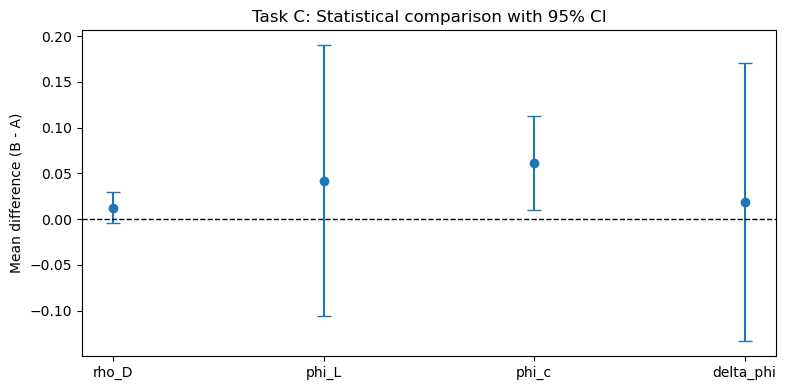

In [94]:
plt.figure(figsize=(8, 4))

xpos = np.arange(len(df_task_c))
means = df_task_c["delta_mu_B_minus_A"].values
err_low = means - df_task_c["ci_low"].values
err_high = df_task_c["ci_high"].values - means

plt.errorbar(
    xpos,
    means,
    yerr=[err_low, err_high],
    fmt="o",
    capsize=5,
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xticks(xpos, df_task_c["metric"].values)
plt.ylabel("Mean difference (B - A)")
plt.title("Task C: Statistical comparison with 95% CI")
plt.tight_layout()
plt.savefig(FIG_DIR / "taskC_mean_difference_ci.png", dpi=150)
plt.show()

## Optional note

In this sample notebook, Condition B is a simple temporally smoothed variant.

For the full course notebook, this can be replaced by:

- MFCC + RASTA
- a different CMVN scope
- one changed feature-design parameter

The statistical comparison procedure remains the same.

## Interim summary after Task C

So far we have completed:

- **Task A**: reconstruction metric $\rho(D)$
- **Task B**: decorrelation metrics $\phi_L$, $\phi_c$, and $\Delta \phi$
- **Task C**: statistical comparison between two conditions

Next, in Task D, we will change exactly one design parameter and observe its effect.

# Task D — Mini Sensitivity Experiment (Improved Version)

In this task, we change exactly **one design parameter** and observe how the feature metrics change.

Parameter examined in this example:

window length

We compare:

- 20 ms
- 25 ms
- 30 ms

while keeping all other settings fixed.

Fixed settings:

- hop length = 10 ms
- number of Mel bands $K = 40$
- $f_{min} = 20$ Hz
- $f_{max} = 8000$ Hz
- MFCC dimension $D = 13$

For each setting we compute:

- reconstruction metric $\rho(D)$
- decorrelation metrics $\phi_L$, $\phi_c$, and $\Delta \phi$

Why this matters:

- shorter windows improve time resolution
- longer windows improve frequency resolution
- the feature metrics show how this design choice affects information preservation and decorrelation

In [95]:
window_values = [20, 25, 30]
results = []

for win_ms in window_values:
    # log-Mel with modified window length
    L_test = compute_logmel(
        y=y,
        sr=sr,
        frame_length_ms=win_ms,
        hop_length_ms=config["hop_length_ms"],   # fixed at 10 ms
        n_fft=config["n_fft"],
        n_mels=config["n_mels"],
        fmin=config["fmin"],
        fmax=config["fmax"],
        epsilon=config["epsilon"],
    )

    # CMVN
    L_test_cmvn = cmvn(L_test)

    # MFCC
    C_test = compute_mfcc_from_logmel(L_test_cmvn, D=config["D"])

    # reconstruction
    L_hat_test = reconstruct_logmel_from_mfcc(C_test, K=config["n_mels"])
    rho_val = flatten_corr(L_test_cmvn, L_hat_test)

    # correlation matrices
    R_L_test = corr_matrix_over_time(L_test_cmvn)
    R_c_test = corr_matrix_over_time(C_test)

    phi_L_test = mean_abs_offdiag(R_L_test)
    phi_c_test = mean_abs_offdiag(R_c_test)
    delta_phi_test = phi_c_test - phi_L_test

    results.append({
        "window_ms": win_ms,
        "rho_D": rho_val,
        "phi_L": phi_L_test,
        "phi_c": phi_c_test,
        "delta_phi": delta_phi_test
    })

df_task_d = pd.DataFrame(results)
df_task_d

,window_ms,rho_D,phi_L,phi_c,delta_phi
0,20,0.948971,0.520736,0.158265,-0.362470
1,25,0.940958,0.513890,0.166284,-0.347606
2,30,0.934779,0.510321,0.170097,-0.340224


## Save Task D results

In [96]:
df_task_d.to_csv(TABLE_DIR / "taskD_sensitivity_window.csv", index=False)
df_task_d

,window_ms,rho_D,phi_L,phi_c,delta_phi
0,20,0.948971,0.520736,0.158265,-0.362470
1,25,0.940958,0.513890,0.166284,-0.347606
2,30,0.934779,0.510321,0.170097,-0.340224


## Plot reconstruction metric vs window length

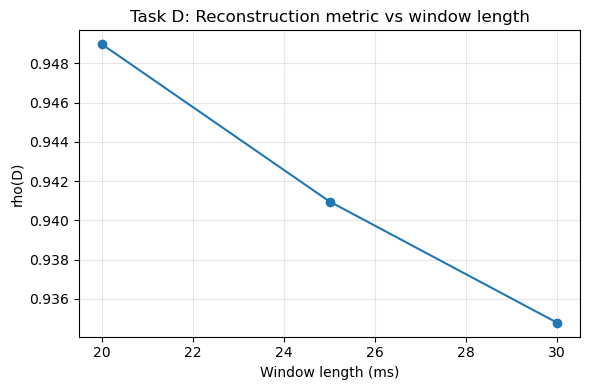

In [97]:
plt.figure(figsize=(6, 4))
plt.plot(df_task_d["window_ms"], df_task_d["rho_D"], marker="o")
plt.title("Task D: Reconstruction metric vs window length")
plt.xlabel("Window length (ms)")
plt.ylabel("rho(D)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plot decorrelation metrics vs window length

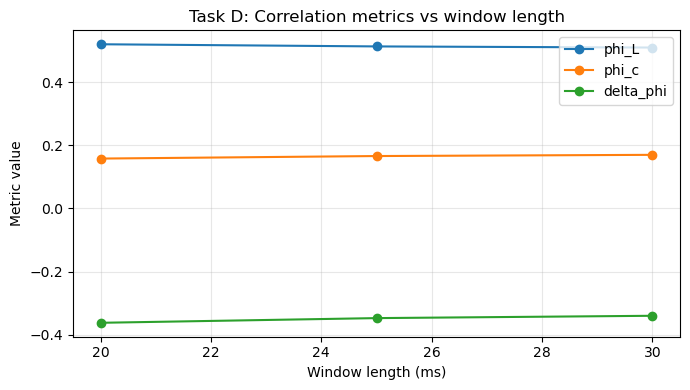

In [98]:
plt.figure(figsize=(7, 4))
plt.plot(df_task_d["window_ms"], df_task_d["phi_L"], marker="o", label="phi_L")
plt.plot(df_task_d["window_ms"], df_task_d["phi_c"], marker="o", label="phi_c")
plt.plot(df_task_d["window_ms"], df_task_d["delta_phi"], marker="o", label="delta_phi")
plt.title("Task D: Correlation metrics vs window length")
plt.xlabel("Window length (ms)")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation

This sensitivity experiment changes only the window length.

Interpretation guide:

- If $\rho(D)$ changes with window length, the reconstruction quality depends on the time–frequency resolution.

- If $\phi_L$ or $\phi_c$ changes, the window length influences the correlation structure of the features.

- If $\Delta \phi$ remains negative, MFCC is still more decorrelated than log-Mel.

In this experiment the metrics change only slightly across 20–30 ms windows.

Main lesson:

feature extraction is not a fixed recipe, but within the typical speech range (20–30 ms) the MFCC pipeline is relatively stable.

In [99]:
print("Task D summary")
print(df_task_d)

best_rho_row = df_task_d.loc[df_task_d["rho_D"].idxmax()]
best_phi_row = df_task_d.loc[df_task_d["phi_c"].idxmin()]

print("\nBest reconstruction (highest rho_D):")
print(best_rho_row)

print("\nMost decorrelated MFCC (smallest phi_c):")
print(best_phi_row)

Task D summary
   window_ms     rho_D     phi_L     phi_c  delta_phi
0         20  0.948971  0.520736  0.158265  -0.362470
1         25  0.940958  0.513890  0.166284  -0.347606
2         30  0.934779  0.510321  0.170097  -0.340224

Best reconstruction (highest rho_D):
window_ms    20.000000
rho_D         0.948971
phi_L         0.520736
phi_c         0.158265
delta_phi    -0.362470
Name: 0, dtype: float64

Most decorrelated MFCC (smallest phi_c):
window_ms    20.000000
rho_D         0.948971
phi_L         0.520736
phi_c         0.158265
delta_phi    -0.362470
Name: 0, dtype: float64


## Final reflection

Write 3–5 sentences:

- What did you observe?
- Which metric changed the most?
- What design choice seems most important?